# Sistemas LTI: control por realimentación de estados estimados

Vamos a estudiar el caso en que no tenemos acceso directo a los estados, y por tanto, dependemos de las salidas para poder controlar por realimentación de estados.

**Controlable y observable:**
$$A_c =\begin{pmatrix}1&2&0 \\ -2&3&0\\ 1&0&-2\end{pmatrix}, \quad B = \begin{pmatrix}1& 2\\ 1&0\\ 0&0\end{pmatrix}, \quad C_o = (1\ 2\ 1)$$

**No controlable y no observable:**
$$A_i =\begin{pmatrix}1&2&0 \\ -2&3&0\\ 0&0&-2\end{pmatrix}, \quad B = \begin{pmatrix}1& 2\\ 1&0\\ 0&0\end{pmatrix}, \quad C_i = (1\ 2\ 0)$$

Recuperamos nuestros sistemas de antes pero ahora, lo que hacemos es añadir la matriz $C$, ya que no podemos realimentar directamente desde los estados.

In [27]:
import numpy as np
import control as ct
from scipy.linalg import expm
from scipy.integrate import quad_vec, solve_ivp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

In [ ]:
Ac = np.array([[1, 2, 0], [-2, 3, 0], [1, 0, -2]])
B  = np.array([[1, 2], [1, 0], [0, 0]])   # comun a los dos sistemas
Co = np.array([[1, 2, 1]])
Ai = np.array([[1, 2, 0], [-2, 3, 0], [0, 0, -2]])
Ci = np.array([[1, 2, 0]])

## Matriz de observabilidad

Calculamos la matriz de observabilidad empleando directamente `control.obsv` (equivalente a `obsv` de MATLAB).

In [29]:
Oo = ct.obsv(Ac, Co)
Oo

array([[  1.,   2.,   1.],
       [ -2.,   8.,  -2.],
       [-20.,  20.,   4.]])

Igual que para la controlabilidad, podríamos usar directamente la definición de la matriz de observabilidad,

$$\mathcal{O} = \begin{pmatrix}C\\ CA\\ CA^2\\ \vdots \\ CA^{n-1}\end{pmatrix}$$

In [30]:
cOo = np.vstack([Co, Co @ Ac, Co @ Ac @ Ac])
print('cOo =\n', cOo)

rOo = np.linalg.matrix_rank(Oo)
print('rank(Oo) =', rOo)

Oi = ct.obsv(Ai, Ci)
rOi = np.linalg.matrix_rank(Oi)
print('Oi =\n', Oi)
print('rank(Oi) =', rOi)

cOo =
 [[  1   2   1]
 [ -2   8  -2]
 [-20  20   4]]
rank(Oo) = 3
Oi =
 [[  1.   2.   0.]
 [ -3.   8.   0.]
 [-19.  18.   0.]]
rank(Oi) = 2


Obtenemos que el primer sistema es observable y el segundo no. En el caso del segundo, es suficiente observar la última columna de la matriz de observabilidad para darse cuenta de que no es observable.

## Test de autovectores

Un par $(A,C)$ es observable si no existe ningún autovector de $A$ en el kernel de $C$.

Calculamos entonces los autovectores y autovalores de las matrices de ambos sistemas.

> **Nota:** `np.linalg.eig(A)` devuelve `(autovalores, autovectores)`, al revés que `[V,D] = eig(A)` de MATLAB.

In [31]:
lc, avc = np.linalg.eig(Ac)
li, avi = np.linalg.eig(Ai)
print('lc =', lc)
print('li =', li)

lc = [-2.+0.j      2.+1.7321j  2.-1.7321j]
li = [ 2.+1.7321j  2.-1.7321j -2.+0.j    ]


De aquí podemos aprender ya muchas cosas de ambos sistemas. Para empezar podemos estudiar directamente la estabilidad de nuestros sistemas examinando los autovalores obtenidos. En ambos casos, obtenemos autovalores con parte real positiva, así que ninguno de los dos sistemas es estable.

Veamos ahora la observabilidad con el test de autovectores. Podemos multiplicar $C$ por las matrices de autovectores que hemos obtenido:

In [32]:
testc = Co @ avc
testi = Ci @ avi
print('testc =', testc)
print('testi =', testi)

testc = [[1.    +0.j     1.5429+1.1453j 1.5429-1.1453j]]
testi = [[1.7678-0.6124j 1.7678+0.6124j 0.    +0.j    ]]


Observamos que en el primer caso, todos los resultados son distintos de cero, por tanto no hay ningún autovector de $A_c$ en el kernel de $C$. Sin embargo el último autovector de $A_i$ da como resultado 0, por tanto dicho autovector está en el kernel de $C$ y el segundo sistema no es observable, como ya sabíamos.

(Recordad que el test exige comprobar que no hay NINGÚN autovector de $A$ en el kernel de $C$ y, por tanto, no se puede hacer del modo directo en que lo hemos hecho aquí si hay autovalores con multiplicidad geométrica mayor que 1; análogo a controlabilidad, hay que comprobar que no hay ningún vector en el subespacio formado por los autovectores en el kernel de $C$.)

## Test de Lyapunov para observabilidad

En este caso, debemos encontrar una solución $W\succ 0$ para la ecuación de Lyapunov:

$$A^TW+WA = -C^TC$$

Hay que recordar que esta ecuación solo se cumple en el caso de que $A$ sea una matriz de estabilidad (Hurwitz); ninguno de nuestros sistemas lo cumple, por lo que no debemos encontrar la solución deseada. Para comprobarlo, empleamos `control.lyap`.

In [33]:
W = ct.lyap(Ac.T, Co.T @ Co)
lW = np.linalg.eigvals(W)
print('W =\n', W)
print('eig(W) =', lW)

W =
 [[-0.3214 -0.7857 -1.75  ]
 [-0.7857 -0.1429  1.5   ]
 [-1.75    1.5     0.25  ]]
eig(W) = [ 2.7057 -1.9405 -0.9795]


La matriz obtenida $W$ no es definida positiva, el sistema no es estable y por eso no obtenemos solución adecuada para la ecuación de Lyapunov. Para comprobar que sí funciona para un sistema estable, vamos a definir una nueva matriz $A_e$,

$$A_e = \begin{pmatrix}-1 &-2& -1\\ 0&-1 &-1\\ 1&-2&-2\end{pmatrix}$$

In [34]:
Ae = np.array([[-1, 2, -1], [0, -1, -1], [1, -2, -2]])
lAe = np.linalg.eigvals(Ae)                          # estable
rank_obsv_Ae = np.linalg.matrix_rank(ct.obsv(Ae, Co))  # observable
print('eig(Ae) =', lAe)
print('rank(obsv(Ae,Co)) =', rank_obsv_Ae)

eig(Ae) = [-3. +0.j    -0.5+0.866j -0.5-0.866j]
rank(obsv(Ae,Co)) = 3


Por tanto la matriz $A_e$ es una matriz de estabilidad y el par $(A_e,C_o)$ es observable. Veamos qué dice ahora el test de Lyapunov,

In [35]:
W = ct.lyap(Ae.T, Co.T @ Co)
lp = np.linalg.eigvals(W)
print('W =\n', W)
print('eig(W) =', lp)

W =
 [[ 0.8974  0.2308  0.3974]
 [ 0.2308  7.5385 -2.5385]
 [ 0.3974 -2.5385  1.3205]]
eig(W) = [0.1444 1.1679 8.4441]


Todos los autovalores son positivos, lo que implica que $W$ es definida positiva.

Podemos obtener también $W$ calculando el gramiano "infinito". Recordad que el gramiano "infinito" es la única solución al test de Lyapunov de estabilidad.

$$W = \int_0^\infty e^{A^T\tau}C^TCe^{A\tau}\,d\tau$$

Definimos una función con el integrando `dgramo`, definido a continuación, y usamos `scipy.integrate.quad_vec`, el integrador para integrandos matriciales.

In [36]:
def dgramo(t, A, C):
    """
    Integrando del gramiano de observabilidad 'infinito' para el par (A, C).
    """
    return expm(A.T * t) @ (C.T @ C) @ expm(A * t)

In [37]:
W, err = quad_vec(lambda t: dgramo(t, Ae, Co), 0, np.inf)
lW = np.linalg.eigvals(W)
print('W =\n', W)
print('eig(W) =', lW)

W =
 [[ 0.8974  0.2308  0.3974]
 [ 0.2308  7.5385 -2.5385]
 [ 0.3974 -2.5385  1.3205]]
eig(W) = [0.1444 1.1679 8.4441]


Por supuesto, obtenemos el mismo resultado que empleando la función `lyap`.

## Estabilización por realimentación de estados estimados

Volvamos a los dos sistemas del principio: el primero debería ser estabilizable por realimentación de estados, empleando la ecuación de Lyapunov. El segundo, no, ya que no es posible encontrar una matriz $W$ que cumpla con el test de Lyapunov para ninguna realimentación de estados.

Sabemos que podemos estabilizar el sistema empleando un parámetro $\mu>0$. Para ello debemos encontrar una matriz $P\succ0$ de modo que satisfaga la ecuación de Lyapunov,

$$P(A-BK)+(A-BK)^TP=-2\mu P$$

Para ello, empezamos por resolver la ecuación de Lyapunov

$$(-\mu I-A)W+W(-\mu I -A)^T = -BB^T$$

Vamos a elegir, por ejemplo, $\mu=3$ (se debe elegir mayor que el menor autovalor de $A_c$, en valor absoluto de la parte real).

Es interesante notar que este procedimiento es el mismo que el empleado para realizar una realimentación de estados directa: **principio de separación** — podemos diseñar independientemente los autovalores del sistema y los del observador.

In [38]:
mu = 3
W = ct.lyap(-mu*np.eye(3) - Ac, B @ B.T)
lW = np.linalg.eigvals(W)
print('W =\n', W)
print('eig(W) =', lW)

W =
 [[ 0.5357  0.1786 -0.087 ]
 [ 0.1786  0.1429 -0.0504]
 [-0.087  -0.0504  0.087 ]]
eig(W) = [0.6232 0.0868 0.0556]


Ahora tomamos $P = W^{-1}$ y la ganancia de nuestra realimentación será $K = \frac{1}{2}B^TP$.

In [39]:
P = np.linalg.inv(W)
K = B.T @ P / 2
K

array([[-0.2098,  4.6341,  2.4732],
       [ 3.2878, -3.7073,  1.1415]])

Podemos comprobar dónde quedan nuestros autovalores en lazo cerrado,

In [40]:
lAccl = np.linalg.eigvals(Ac - B @ K)
lAccl

array([-3.+3.0138j, -3.-3.0138j, -3.+0.j    ])

Todos con parte real menor o igual a $-\mu$.

En nuestro caso, no podemos emplear directamente los estados para realimentar y así estabilizar nuestro sistema. Debemos por tanto implementar un estimador. Para el primer sistema, esto es siempre posible, ya que nuestro sistema es observable.

Definimos un observador de la forma,

$$\dot{\hat x} = A\hat x + Bu - L(\hat y-y)$$

Es decir, realimentamos la salida, para asegurar que el estimador y el sistema van a converger en el tiempo.

Recordad que esta entrada hace que el error $e(t) =\hat x(t) - x(t)$ tienda a cero cuando $t \rightarrow \infty$:

$$\dot e(t) = \dot{\hat x}(t) - \dot x(t) = (A -LC)e(t)$$

si elegimos la ganancia $L$ adecuadamente. Para hacerlo, es suficiente obtener una ganancia que estabilice el par $(A^T,C^T)$, y podemos emplear las mismas técnicas que hemos empleado en el caso de sistemas controlables.

### Obtención de $L$ mediante el método de Lyapunov

Aplicamos el método de Lyapunov para estabilizar el par $(A^T,C^T)$.

$$P(A^T-C^TK)+(A^T-C^TK)^TP=-2\mu P$$

$$(-\mu I-A^T)W+W(-\mu I -A) = -C^TC$$

Vamos a elegir, por ejemplo, $\mu=5$. Se debe elegir de modo que la parte real de los autovalores del estimador sea menor que los correspondientes al sistema realimentado, de este modo el estimador converge al sistema más rápido de lo que éste último converge a 0.

In [41]:
mu = 5
W = ct.lyap(-mu*np.eye(3) - Ac.T, Co.T @ Co)
lW = np.linalg.eigvals(W)
print('W =\n', W)
print('eig(W) =', lW)

W =
 [[0.1108 0.1462 0.1278]
 [0.1462 0.2134 0.1586]
 [0.1278 0.1586 0.1667]]
eig(W) = [0.4587 0.0023 0.0298]


Ahora tomamos $P = W^{-1}$ y la ganancia de nuestra realimentación será $K = \frac{1}{2}CP$. Por último recordar que para nuestro observador debemos tomar $L = K^T$.

In [42]:
L = (Co @ np.linalg.inv(W)).T / 2
L

array([[-29.1667],
       [ 19.8333],
       [  6.5   ]])

Podemos comprobar que la matriz $A-LC$ es una matriz de estabilidad,

In [43]:
np.linalg.eigvals(Ac - L @ Co)

array([-5.+9.6954j, -5.-9.6954j, -5.+0.j    ])

Y comprobar cómo estima nuestro estimador (ver la función `estimador_lineal` definida a continuación).

In [44]:
def estimador_lineal(t, xt, A, C, L):
    """
    Separa los estados de la planta de los del estimador. Deben ir
    concatenados en el mismo vector para que solve_ivp los integre juntos.
    """
    n = len(xt) // 2
    x = xt[:n]        # estados del sistema
    xhat = xt[n:]      # estados del estimador
    xdot = A @ x                            # no le doy entrada, lo dejo evolucionar
    xhatdot = A @ xhat - L @ C @ (xhat - x)
    return np.concatenate([xdot, xhatdot])

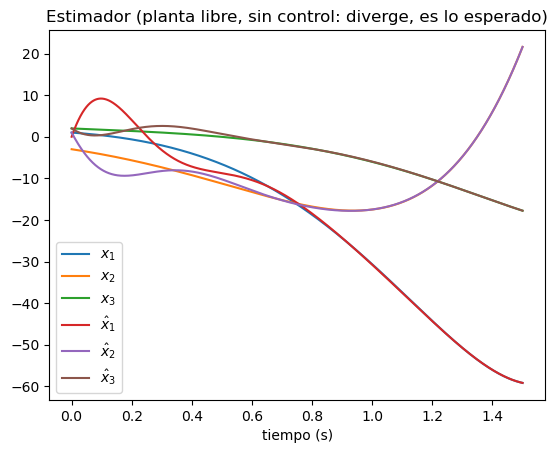

In [45]:
tf = 1.5
x0 = [1, -3, 2, 0, 1, 2]  # 3 primeras: estado. 3 siguientes: estimador

sol = solve_ivp(estimador_lineal, [0, tf], x0, args=(Ac, Co, L), max_step=1e-3)

plt.figure(1)
plt.plot(sol.t, sol.y.T)
plt.legend([r'$x_1$', r'$x_2$', r'$x_3$', r'$\hat{x}_1$', r'$\hat{x}_2$', r'$\hat{x}_3$'])
plt.xlabel('tiempo (s)')
plt.title('Estimador (planta libre, sin control: diverge, es lo esperado)')
plt.show()

Ojo: la planta aquí no tiene entrada de control, y $A_c$ es inestable, así que **los estados divergen** — lo importante es que el estimador $\hat x$ converge a $x$ con el paso del tiempo, que es lo que queríamos comprobar.

## Control por realimentación de estados estimados

Ahora tenemos todos los ingredientes para diseñar nuestro control por realimentación de estados estimados. Para ello, construimos el sistema ampliado,

$$\begin{pmatrix}\dot{x} \\ \dot{\hat{x}}\end{pmatrix} = \begin{pmatrix}A & 0\\ 0 & A-BK-LC \end{pmatrix}\begin{pmatrix}x \\ \hat{x}\end{pmatrix}+\begin{pmatrix}B\\ 0\end{pmatrix}u +\begin{pmatrix}0\\ L\end{pmatrix}y$$
$$u = -K\hat{x}, \qquad y = Cx, \qquad \hat{y} = C\hat{x}$$

No es la única forma de representarlo, pero en ésta se subraya que la única entrada al sistema es $u$ y la única entrada al estimador es $y$.

Para facilitar el cálculo al integrador, es buena idea construir una sola matriz ampliada con todas las realimentaciones ya incluidas.

In [46]:
Amp = np.block([
    [Ac,       -B @ K],
    [L @ Co,   Ac - B @ K - L @ Co]
])
Amp

array([[  1.    ,   2.    ,   0.    ,  -6.3659,   2.7805,  -4.7561],
       [ -2.    ,   3.    ,   0.    ,   0.2098,  -4.6341,  -2.4732],
       [  1.    ,   0.    ,  -2.    ,   0.    ,   0.    ,   0.    ],
       [-29.1667, -58.3333, -29.1667,  23.8008,  63.1138,  24.4106],
       [ 19.8333,  39.6667,  19.8333, -21.6236, -41.3008, -22.3065],
       [  6.5   ,  13.    ,   6.5   ,  -5.5   , -13.    ,  -8.5   ]])

Creamos una función para pasársela a `solve_ivp` como en los ejemplos anteriores.

In [47]:
def sistema_lineal_obs(t, x, A):
    """
    El estado x debe incluir tanto los estados como los del observador.
    Solo se usa una matriz A, que debe ser la ampliada con todas las
    realimentaciones incluidas (primero los estados, despues los estimadores).
    """
    return A @ x

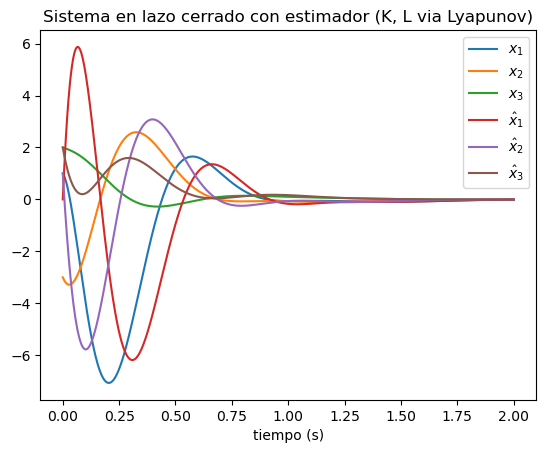

In [48]:
tf = 2
x0 = [1, -3, 2, 0, 1, 2]

sol = solve_ivp(sistema_lineal_obs, [0, tf], x0, args=(Amp,), max_step=1e-3)

plt.figure(2)
plt.plot(sol.t, sol.y.T)
plt.legend([r'$x_1$', r'$x_2$', r'$x_3$', r'$\hat{x}_1$', r'$\hat{x}_2$', r'$\hat{x}_3$'])
plt.xlabel('tiempo (s)')
plt.title('Sistema en lazo cerrado con estimador (K, L via Lyapunov)')
plt.show()

## Diseño alternativo con `place`

Además de colocar los autovalores empleando el método de Lyapunov, podemos colocarlos empleando `control.place`. Esto nos da libertad para poner los autovalores del controlador y del estimador donde queramos.

Primero colocamos los del controlador; nuestro sistema tiene dimensión $n=3$, luego debemos colocar tres autovalores, por ejemplo $\lambda = [-3, -4, -5]$.

In [49]:
lam = [-3, -4, -5]
K = ct.place(Ac, B, lam)
print('K =\n', K)
print('eig(Ac - B@K) =', np.linalg.eigvals(Ac - B @ K))

K =
 [[-1.9977  7.      0.0045]
 [ 4.4989 -2.4998  1.4977]]
eig(Ac - B@K) = [-5. -3. -4.]


Ahora ponemos los del estimador; procuramos ponerlos a la izquierda de los del controlador, para que el estimador converja antes: $\lambda = [-4,-5,-6]$.

In [50]:
lam2 = [-4, -5, -6]
K2 = ct.place(Ac.T, Co.T, lam2)
L = K2.T
print('L =\n', L)
print('eig(Ac - L@Co) =', np.linalg.eigvals(Ac - L @ Co))

L =
 [[-5.4167]
 [11.9167]
 [-1.4167]]
eig(Ac - L@Co) = [-6. -5. -4.]


Podemos, igual que antes, ver cómo se comporta nuestro estimador,

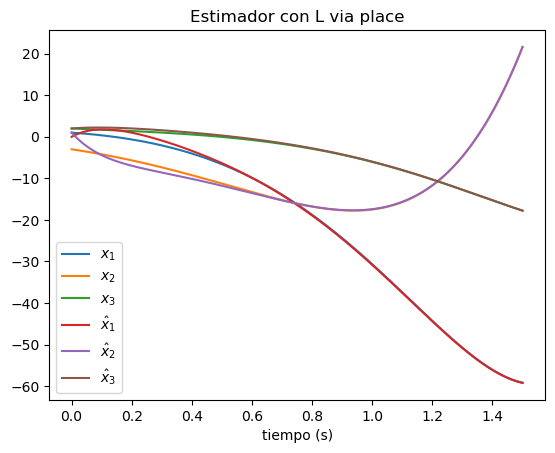

In [51]:
tf = 1.5
x0 = [1, -3, 2, 0, 1, 2]

sol = solve_ivp(estimador_lineal, [0, tf], x0, args=(Ac, Co, L), max_step=1e-3)

plt.figure(3)
plt.plot(sol.t, sol.y.T)
plt.legend([r'$x_1$', r'$x_2$', r'$x_3$', r'$\hat{x}_1$', r'$\hat{x}_2$', r'$\hat{x}_3$'])
plt.xlabel('tiempo (s)')
plt.title('Estimador con L via place')
plt.show()

Los autovalores tienen parte real más negativa, así que todo es más rápido.

Por último podemos emplear la realimentación con los estados estimados (con K y L de `place`) para estabilizar nuestro sistema,

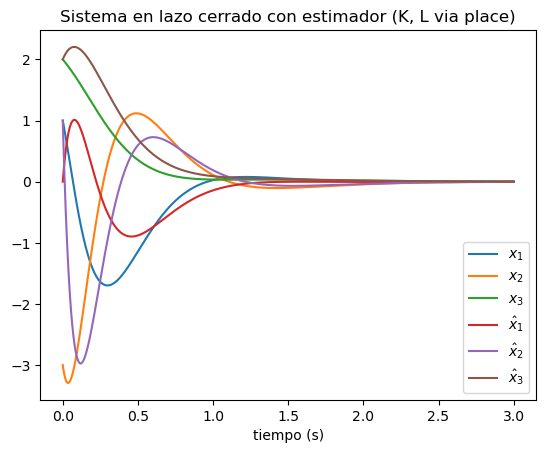

In [52]:
Amp = np.block([
    [Ac,       -B @ K],
    [L @ Co,   Ac - B @ K - L @ Co]
])

tf = 3
x0 = [1, -3, 2, 0, 1, 2]

sol = solve_ivp(sistema_lineal_obs, [0, tf], x0, args=(Amp,), max_step=1e-3)

plt.figure(4)
plt.plot(sol.t, sol.y.T)
plt.legend([r'$x_1$', r'$x_2$', r'$x_3$', r'$\hat{x}_1$', r'$\hat{x}_2$', r'$\hat{x}_3$'])
plt.xlabel('tiempo (s)')
plt.title('Sistema en lazo cerrado con estimador (K, L via place)')
plt.show()